# Libraries and dependencies

In [1]:
#Libraries and dependencies 
import cv2
import cc3d
import math
import mrcfile
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import imagecodecs

import time
import tifffile as tiff
from tifffile import imread
from PIL import Image

import scipy as scipy
from scipy.ndimage import center_of_mass, sum as ndimage_sum
from scipy.stats import linregress, kurtosis, mode
from scipy import ndimage
from scipy.ndimage import map_coordinates

from sklearn.preprocessing import StandardScaler


import os
import glob
import sys

from scipy.ndimage import distance_transform_edt
import gc

import seaborn as sns
from scipy.stats import ttest_ind


# Dictionaries 

In [2]:
#File paths on personal computer 

#No Stimulation
directoryNS = "D:/Downloads/Drug Stimulated INS1E Cells/NS"

#No stimulation files listed here (6 final cells used in total)
NS_7_22_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_7_22_pre_rec*.mrc")
NS_6_5_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_6_5_pre_rec*.mrc")
NS_1537_16_18_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_1537_16-18_pre_rec*.mrc")
NS_7_8_9_files = glob.glob(directoryNS + '/**/' + "/*White_PBC_INS1e_0min_7_8-9_pre_rec*.mrc")
NS_6_17_19_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_6_17-19_pre_rec*.mrc")
NS_1537_19_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_1537_19_pre_rec*.mrc")

#NS_6_10_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_6_10_pre_rec*.mrc")
#6_10 remove from analysis, only 190 vesicles compared to average of 700 vesicles 

In [3]:
#Creating a LAC factor dictionary 

#Reading in Excel File
sheet_names = ['NS', 'Glucose', 'Glucose + GIP', 'Glucose +TAK', 'Glucose + GKA', "Glucose + GLM"]
LACfactorfile = r"C:/Users/kchang42/Jupyter Code/Vesicle Analysis for Drug Stimulated Cells/LAC Factors(4 conditions).xlsx"
LACfactors = pd.read_excel(LACfactorfile, sheet_name=sheet_names)

#Creating dataframe for all the features
NSfact = LACfactors['NS']
Glufac = LACfactors['Glucose']
GIPfac = LACfactors['Glucose + GIP']
TAKfac = LACfactors['Glucose +TAK']
GKAfac = LACfactors['Glucose + GKA']
GLMfac = LACfactors['Glucose + GLM']

#Ext dataframe
LAC_fact_Ext = pd.read_csv("D:/Downloads/Drug Stimulated INS1E Cells/Exendin_Glucose/Ext_4_LAC_factors.txt")
LAC_fact_Ext

#Combining dataframes 
CombinedLACfactors = pd.concat([NSfact, Glufac, GIPfac, TAKfac, GKAfac, GLMfac, LAC_fact_Ext])
LACfactordict = CombinedLACfactors.set_index('Cell Name')['LAC Factor'].to_dict()

In [4]:
LACfactordict

{'6_5': 33.33,
 '6_10': 33.33,
 '6_17-19': 30.74,
 '1537_19': 33.33,
 '7_22': 33.33,
 '1537_16-18': 33.33,
 '7_8=9': 33.33,
 '9905_12-13': 32.89,
 '9908_4-5': 30.21,
 '9905_3': 32.89,
 '9905_8': 32.89,
 '9905_11-12': 32.89,
 '9905_7': 32.89,
 '9905_6': 32.89,
 '1152_15-17': 32.89,
 '1535_5-7': 33.33,
 '2216_3-5': 33.33,
 '2216_6-7': 33.33,
 '2220_9': 33.33,
 '2220_12-13': 33.33,
 '2220_5': 33.33,
 '2220_4': 33.33,
 '2211_9-11': 33.33,
 '2213_11-12': 33.33,
 '1529_1-3': 33.33,
 '2213_4': 32.89,
 '9917_1': 32.89,
 '9917_2': 32.89,
 '9919_12-13': 32.89,
 '9919_8-9': 32.89,
 '9892_5-6': 32.89,
 '9889_9': 29.07,
 '9889_6': 30.21,
 '9892_3': 32.89,
 '9897_1': 32.89,
 '9895_1': 32.89,
 '9929_10-11': 29.07,
 '9928_6': 32.89,
 '9930_8-10': 29.07,
 '9929_3': 32.89,
 '9929_12': 29.07,
 '9928_2-3': 32.89,
 '1518_14': 30.74,
 '9910_4': 30.21,
 '9913_3-4': 32.89,
 '9913_5-6': 32.89,
 '9913_1-2': 32.89,
 '9911_2': 32.89}

# Functions

In [11]:
def openmrc(raw_mrc):
    #os.path.splittext splits a file path into two parts: a root (before the final .) and a extension (after the last . , e.g. the file type)
    file_extension = os.path.splitext(raw_mrc)[1]
    
    if file_extension == ".mrc": 
        with mrcfile.open(raw_mrc, mode = 'r+', permissive = True) as mrc:
            mrc.header.map = mrcfile.constants.MAP_ID
            LAC_dat = mrc.data
    else:
        LAC_data = imread(raw_mrc)
        LAC_dat = np.flip(LAC_data, axis = 1)  #Rotate orientation so same as mrc files 

    return LAC_dat

In [5]:
#gives individual granules a label based on connectivity

def label_granules(gran_mask, connectivity=6):
    """
    Load a binary granule mask if needed and label connected components.

    Returns
    -------
    labels_img : ndarray
        0 = background, 1..N = granules
    """
    if isinstance(gran_mask, (str, bytes, os.PathLike)):
        gran_data = openmrc(gran_mask)
    else:
        gran_data = np.asarray(gran_mask)

    gran_binary = gran_data > 0

    labels_img = cc3d.connected_components(
        gran_binary.astype(np.uint8),
        connectivity=connectivity
    )

    return labels_img

In [6]:
#Generate local granule neighborhoods based on threshold

def granule_neighborhoods_local(
    gran_mask,
    LACfactor,
    distance_nm=100,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
):
    """
    Compute voxels within distance_nm of each granule.

    Returns
    -------
    neighborhoods : dict
        If return_coords=True:
            neighborhoods[lab] = (N, 3) array of voxel coordinates in full volume
        Else:
            neighborhoods[lab] = full-volume boolean mask

    dist_maps : dict
        dist_maps[lab] = local distance map in nm for the padded subvolume

    pad_slices : dict
        pad_slices[lab] = tuple of slices into the full volume for the local crop

    labels_img : ndarray
        Labeled granule volume
    """
    voxel_size_nm = 1000.0 / LACfactor

    labels_img = label_granules(gran_mask, connectivity=6)

    labels = np.unique(labels_img)
    labels = labels[labels != 0]

    slices = ndimage.find_objects(labels_img)
    pad_vox = int(np.ceil(distance_nm / voxel_size_nm))

    neighborhoods = {}
    dist_maps = {} if return_dist_maps else None
    pad_slices = {} if return_pad_slices else None

    for lab in labels:
        sl = slices[lab - 1]
        if sl is None:
            continue

        pad_sl = tuple(
            slice(
                max(0, s.start - pad_vox),
                min(labels_img.shape[ax], s.stop + pad_vox)
            )
            for ax, s in enumerate(sl)
        )

        crop = (labels_img[pad_sl] == lab)

        dist_nm = ndimage.distance_transform_edt(
            ~crop,
            sampling=voxel_size_nm
        )

        neigh = dist_nm <= distance_nm

        if return_coords:
            coords = np.argwhere(neigh) + np.array([s.start for s in pad_sl])
            neighborhoods[lab] = coords
        else:
            full_mask = np.zeros_like(labels_img, dtype=bool)
            full_mask[pad_sl] = neigh
            neighborhoods[lab] = full_mask

        if return_dist_maps:
            dist_maps[lab] = dist_nm

        if return_pad_slices:
            pad_slices[lab] = pad_sl

    outputs = [neighborhoods]
    if return_dist_maps:
        outputs.append(dist_maps)
    if return_pad_slices:
        outputs.append(pad_slices)
    outputs.append(labels_img)

    return tuple(outputs)

In [7]:
#Helper function to calculate granule LAC and Diameter statistics 

def granule_lac_diameter_stats(labels_img, LAC_mrc, LACfactor):
    """
    Compute per-granule LAC statistics and geometric diameter from a labeled granule mask.

    Parameters
    ----------
    labels_img : str or ndarray
        Labeled granule image (0 = background, 1..N = granules).
    LAC_mrc : str or ndarray
        LAC volume in MRC format or already-loaded array.
    LACfactor : float
        Conversion factor used to scale LAC values and convert voxels to nm.

    Returns
    -------
    df_Ves : pandas.DataFrame
        One row per granule label with LAC and geometric measurements.
    """
    labels_img = openmrc(labels_img) if isinstance(labels_img, (str, bytes, os.PathLike)) else np.asarray(labels_img)
    openLAC_mrc = openmrc(LAC_mrc) if isinstance(LAC_mrc, (str, bytes, os.PathLike)) else np.asarray(LAC_mrc)

    # Resolution is (1/LAC factor) * 1000
    Resolution = (1 / LACfactor) * 1000

    Ves_number = len(np.unique(labels_img)) - 1
    if Ves_number <= 0:
        return pd.DataFrame()

    # Centroids
    Ves_centers = center_of_mass(
        np.ones_like(labels_img),
        labels_img,
        range(1, Ves_number + 1)
    )

    df_Ves = pd.DataFrame(Ves_centers, columns=['Centroid X', 'Centroid Y', 'Centroid Z'])
    df_Ves['Group'] = range(1, Ves_number + 1)

    # Map every labeled voxel to its group
    locations = np.argwhere(labels_img != 0)
    location_labels = labels_img[locations[:, 0], locations[:, 1], locations[:, 2]]

    locations_df = pd.DataFrame(locations, columns=['X', 'Y', 'Z'])
    locations_df['Group'] = location_labels

    # Pull LAC values for all granule voxels
    lac_values = (openLAC_mrc * LACfactor)[locations_df['X'].values, locations_df['Y'].values, locations_df['Z'].values]
    locations_df['LAC Value'] = lac_values

    # LAC statistics
    df_Ves['LAC Value'] = locations_df.groupby('Group')['LAC Value'].mean().values
    df_Ves['LAC Max'] = locations_df.groupby('Group')['LAC Value'].max().values
    df_Ves['LAC Min'] = locations_df.groupby('Group')['LAC Value'].min().values
    df_Ves['LAC Std Dev'] = locations_df.groupby('Group')['LAC Value'].std().values
    df_Ves['LAC Skew'] = locations_df.groupby('Group')['LAC Value'].skew().values
    df_Ves['LAC Kurtosis'] = locations_df.groupby('Group')['LAC Value'].apply(kurtosis).values
    df_Ves['LAC Median'] = locations_df.groupby('Group')['LAC Value'].median().values
    df_Ves['LAC 25th Quantile'] = locations_df.groupby('Group')['LAC Value'].apply(np.quantile, 0.25).values
    df_Ves['LAC 75th Quantile'] = locations_df.groupby('Group')['LAC Value'].apply(np.quantile, 0.75).values

    # Volume
    volumes = ndimage_sum(np.ones_like(labels_img), labels_img, range(1, Ves_number + 1))
    df_Ves['Volume (um3)'] = volumes * (Resolution ** 3) * ((1 / 1000) ** 3)

    # Geometric diameter
    x_dis = locations_df.groupby('Group')['X'].max().values - locations_df.groupby('Group')['X'].min().values
    y_dis = locations_df.groupby('Group')['Y'].max().values - locations_df.groupby('Group')['Y'].min().values
    z_dis = locations_df.groupby('Group')['Z'].max().values - locations_df.groupby('Group')['Z'].min().values

    Geo_mean_dia = (x_dis * y_dis * z_dis) ** (1 / 3)
    df_Ves['Geometric Diameter (nm)'] = Geo_mean_dia * Resolution

    return df_Ves

In [8]:
#Count overlap of neighborhoods with mitochondria and cytoplasm masks. Also calculate if granule if contact or not based on local distances. 
#Uses additional function to calculate granule LAC and Diameter statistics 

def count_neighborhood_overlap(
    neigh, dist_maps, pad_slices,
    labels_img, LAC_mrc, LACfactor,
    PM_mask, mito_mask, nucl_mask, Gran_mask
):
    """
    Count overlaps in each granule neighborhood and add per-granule LAC + diameter stats.

    Parameters
    ----------
    neigh : dict
        neigh[label] = array of voxel coordinates with shape (N, 3)
    dist_maps : dict
        dist_maps[label] = local distance map in nm for the padded subvolume
    pad_slices : dict
        pad_slices[label] = tuple of slices into the full volume for that subvolume
    labels_img : str or ndarray
        Labeled granule image (0 = background, 1..N = granules).
    LAC_mrc : str or ndarray
        LAC volume.
    LACfactor : float
        LAC scaling factor used to compute resolution.
    PM_mask, mito_mask, nucl_mask, Gran_mask : str or ndarray
        Paths to MRC files or already-loaded masks.

    Returns
    -------
    counts_df : pandas.DataFrame
        Overlap metrics plus LAC and geometric measurements per granule.
    """
    rows = []

    # Convert masks to boolean arrays
    pm_mask = openmrc(PM_mask) > 0 if isinstance(PM_mask, (str, bytes, os.PathLike)) else (PM_mask > 0)
    gran_mask = openmrc(Gran_mask) > 0 if isinstance(Gran_mask, (str, bytes, os.PathLike)) else (Gran_mask > 0)
    mito_mask = openmrc(mito_mask) > 0 if isinstance(mito_mask, (str, bytes, os.PathLike)) else (mito_mask > 0)
    nucl_mask = openmrc(nucl_mask) > 0 if isinstance(nucl_mask, (str, bytes, os.PathLike)) else (nucl_mask > 0)

    # Cytoplasm = PM minus nucleus
    cyto_mask = pm_mask & ~nucl_mask

    for lab, coords in neigh.items():
        if coords is None or len(coords) == 0:
            rows.append({
                "label": lab,
                "cyto_voxels": 0,
                "mito_voxels": 0,
                "mito_over_cyto_voxels": np.nan,
                "mito_within_50nm": 0,
                "mito_within_50nm_flag": 0
            })
            continue

        z, y, x = coords[:, 0], coords[:, 1], coords[:, 2]

        cyto_hits = cyto_mask[z, y, x]
        mito_hits = mito_mask[z, y, x]

        # Local mitochondria contact within 50 nm
        dist_nm = dist_maps[lab]
        pad_sl = pad_slices[lab]
        local_mito = mito_mask[pad_sl]
        mito_within_50 = local_mito & (dist_nm < 50)

        rows.append({
            "label": lab,
            "cyto_voxels": int(cyto_hits.sum()),
            "mito_voxels": int(mito_hits.sum()),
            "mito_over_cyto_voxels": float(mito_hits.sum() / cyto_hits.sum()) if cyto_hits.sum() > 0 else np.nan,
            "mito_within_50nm": int(mito_within_50.sum()),
            "mito_within_50nm_flag": 1 if mito_within_50.any() else 0
        })

    counts_df = pd.DataFrame(rows)

    # Add LAC + diameter stats per granule
    lac_dia_df = granule_lac_diameter_stats(labels_img, LAC_mrc, LACfactor)

    if not lac_dia_df.empty:
        counts_df = counts_df.merge(
            lac_dia_df,
            left_on="label",
            right_on="Group",
            how="left"
        ).drop(columns=["Group"])

    return counts_df

In [9]:
#Combined Function
def granule_neighborhood_overlap(
    fileslist,
    LACfactor,
    distance_nm=500,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
):
    """
    Run granule_neighborhoods_local + count_neighborhood_overlap in one step.

    Parameters
    ----------
    fileslist : sequence
        [PM_mask, mito_mask, nucl_mask, Gran_mask]
    LACfactor : float
        LAC factor used to convert voxels to nm.
    distance_nm : float
        Neighborhood distance threshold in nm.
    return_coords, return_dist_maps, return_pad_slices : bool
        Match the underlying granule_neighborhoods_local return behavior.
        Note: count_neighborhood_overlap requires coords, dist_maps, and pad_slices,
        so they are computed internally regardless of these flags.

    Returns
    -------
    If return_coords=True, return_dist_maps=True, return_pad_slices=True:
        counts_df, neigh, dist_maps, pad_slices, labels_img
    Otherwise:
        counts_df plus whichever of neigh / dist_maps / pad_slices were requested,
        followed by labels_img.
    """
    if len(fileslist) < 5:
        raise ValueError("fileslist must contain [PM_mask, mito_mask, nucl_mask, Gran_mask, LAC_mrc].")

    PM_mask, mito_mask, nucl_mask, Gran_mask, LAC_mrc  = fileslist[:5]

    # Always compute all intermediates needed for counting
    neigh, dist_maps, pad_slices, labels_img = granule_neighborhoods_local(
        Gran_mask,
        LACfactor=LACfactor,
        distance_nm=distance_nm,
        return_coords=True,
        return_dist_maps=True,
        return_pad_slices=True,
    )

    counts_df = count_neighborhood_overlap(
        neigh,
        dist_maps,
        pad_slices,
        labels_img,
        LAC_mrc = LAC_mrc,
        LACfactor = LACfactor,
        PM_mask=PM_mask,
        mito_mask=mito_mask,
        nucl_mask=nucl_mask,
        Gran_mask=Gran_mask,
    )

    outputs = [counts_df]

    if return_coords:
        outputs.append(neigh)
    if return_dist_maps:
        outputs.append(dist_maps)
    if return_pad_slices:
        outputs.append(pad_slices)

    outputs.append(labels_img)

    return tuple(outputs)

# Testing Functions

In [379]:
#calculate local granule neighborhoods 

neigh, dist_maps, pad_slices, labels_img = granule_neighborhoods_local(
    NS_1537_19_files[3],
    LACfactor=LACfactordict["1537_19"],
    distance_nm=500,
    return_coords=True,
    return_dist_maps = True,
    return_pad_slices=True
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


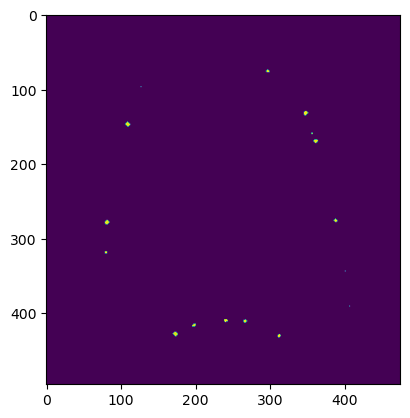

In [381]:
plt.imshow(labels_img[200])
plt.show()

In [392]:
#calculate overlap with mitochondria/cytoplasm voxel masks

counts_df = count_neighborhood_overlap(
    neigh, dist_maps, pad_slices,
    labels_img,
    LAC_mrc = NS_1537_19_files[4],
    LACfactor = LACfactordict["1537_19"],
    PM_mask= NS_1537_19_files[0],
    mito_mask= NS_1537_19_files[1],
    nucl_mask= NS_1537_19_files[2],
    Gran_mask= NS_1537_19_files[3]
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [393]:
counts_df

,label,cyto_voxels,mito_voxels,mito_over_cyto_voxels,mito_within_50nm,mito_within_50nm_flag,Centroid X,Centroid Y,Centroid Z,LAC Value,LAC Max,LAC Min,LAC Std Dev,LAC Skew,LAC Kurtosis,LAC Median,LAC 25th Quantile,LAC 75th Quantile,Volume (um3),Geometric Diameter (nm)
0,1,13327,141,0.010580,0,0,73.237500,263.700000,252.012500,0.307060,0.346424,0.256875,0.022202,-0.183304,-0.761685,0.309746,0.288654,0.323563,0.002161,150.015002
1,2,22169,23,0.001037,0,0,76.850877,383.903509,215.754386,0.300995,0.355197,0.254046,0.022650,0.144516,-0.389380,0.300367,0.285002,0.315677,0.003079,169.403426
2,3,19894,1882,0.094601,0,0,75.581818,384.818182,271.072727,0.328830,0.375614,0.283468,0.019944,-0.112387,-0.285448,0.327869,0.318648,0.343884,0.001485,117.457775
3,4,24728,816,0.032999,0,0,78.165049,294.111650,236.757282,0.343917,0.428766,0.298872,0.021490,0.751627,1.180491,0.341721,0.329744,0.357138,0.005564,208.582457
4,5,21081,1821,0.086381,0,0,77.333333,319.015873,244.650794,0.321087,0.370639,0.265886,0.021179,0.025024,-0.163167,0.320079,0.304747,0.336763,0.001702,139.261591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,820,18978,0,0.000000,0,0,398.714286,374.100000,277.442857,0.341419,0.398684,0.278371,0.022494,-0.616688,0.706583,0.345748,0.330875,0.354459,0.001891,147.987523
820,821,19736,0,0.000000,0,0,400.057143,372.114286,266.342857,0.335910,0.365674,0.293998,0.016570,-0.379847,-0.189990,0.337066,0.328188,0.348624,0.001891,139.261591
821,822,23245,0,0.000000,0,0,401.348000,400.024000,264.264000,0.373556,0.435755,0.284875,0.026402,-0.337575,-0.132086,0.374776,0.355870,0.392840,0.006752,235.890315
822,823,20226,0,0.000000,0,0,403.783019,404.886792,233.028302,0.348780,0.397968,0.298770,0.019457,0.059488,-0.191630,0.350133,0.334463,0.359760,0.002863,165.552006


In [397]:
#where above 0 mito ratio. Keep only mito/cytoplasm ratio, as well as if in contact or not
subset_counts = counts_df[counts_df["mito_over_cyto_voxels"] > 0]
subset_counts

,label,cyto_voxels,mito_voxels,mito_over_cyto_voxels,mito_within_50nm,mito_within_50nm_flag,Centroid X,Centroid Y,Centroid Z,LAC Value,LAC Max,LAC Min,LAC Std Dev,LAC Skew,LAC Kurtosis,LAC Median,LAC 25th Quantile,LAC 75th Quantile,Volume (um3),Geometric Diameter (nm)
0,1,13327,141,0.010580,0,0,73.237500,263.700000,252.012500,0.307060,0.346424,0.256875,0.022202,-0.183304,-0.761685,0.309746,0.288654,0.323563,0.002161,150.015002
1,2,22169,23,0.001037,0,0,76.850877,383.903509,215.754386,0.300995,0.355197,0.254046,0.022650,0.144516,-0.389380,0.300367,0.285002,0.315677,0.003079,169.403426
2,3,19894,1882,0.094601,0,0,75.581818,384.818182,271.072727,0.328830,0.375614,0.283468,0.019944,-0.112387,-0.285448,0.327869,0.318648,0.343884,0.001485,117.457775
3,4,24728,816,0.032999,0,0,78.165049,294.111650,236.757282,0.343917,0.428766,0.298872,0.021490,0.751627,1.180491,0.341721,0.329744,0.357138,0.005564,208.582457
4,5,21081,1821,0.086381,0,0,77.333333,319.015873,244.650794,0.321087,0.370639,0.265886,0.021179,0.025024,-0.163167,0.320079,0.304747,0.336763,0.001702,139.261591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,791,21693,866,0.039921,0,0,385.260870,254.173913,184.728261,0.351438,0.402714,0.291140,0.023924,-0.113237,-0.698596,0.352618,0.332679,0.369194,0.002485,159.414727
792,793,20760,9,0.000434,0,0,385.471698,205.773585,253.396226,0.279646,0.308227,0.228106,0.015990,-0.417549,0.500915,0.279058,0.268396,0.289839,0.001431,117.457775
798,799,21595,169,0.007826,0,0,390.739130,241.021739,244.934783,0.305127,0.344066,0.259917,0.017393,-0.307484,-0.353024,0.305125,0.294153,0.318451,0.002485,169.403426
804,805,20469,92,0.004495,0,0,392.213333,254.586667,246.253333,0.322318,0.378416,0.279585,0.018735,0.523785,0.362566,0.321577,0.308895,0.333645,0.002026,139.261591


In [402]:
# Create 10 bins
subset_counts["bin"] = pd.cut(
    subset_counts["mito_over_cyto_voxels"],
    bins=15
)

# Calculate percentage of 1s in each bin
bin_summary = (
    subset_counts
    .groupby("bin")["mito_within_50nm_flag"]
    .agg(
        total="count",
        positives="sum"
    )
    .assign(
        percent_ones=lambda x: 100 * x["positives"] / x["total"]
    )
    .reset_index()
)

print(bin_summary)

                    bin  total  positives  percent_ones
0   (-0.000177, 0.0147]    148          0      0.000000
1      (0.0147, 0.0293]     55          0      0.000000
2       (0.0293, 0.044]     49          0      0.000000
3       (0.044, 0.0586]     38          1      2.631579
4      (0.0586, 0.0733]     23          1      4.347826
5      (0.0733, 0.0879]     22          1      4.545455
6       (0.0879, 0.103]     13          2     15.384615
7        (0.103, 0.117]     13          2     15.384615
8        (0.117, 0.132]      6          2     33.333333
9        (0.132, 0.147]      5          1     20.000000
10       (0.147, 0.161]      2          1     50.000000
11       (0.161, 0.176]      1          0      0.000000
12        (0.176, 0.19]      1          1    100.000000
13        (0.19, 0.205]      0          0           NaN
14        (0.205, 0.22]      1          0      0.000000


C:\Users\kchang42\AppData\Local\Temp\ipykernel_45736\42518236.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_counts["bin"] = pd.cut(
C:\Users\kchang42\AppData\Local\Temp\ipykernel_45736\42518236.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")["mito_within_50nm_flag"]


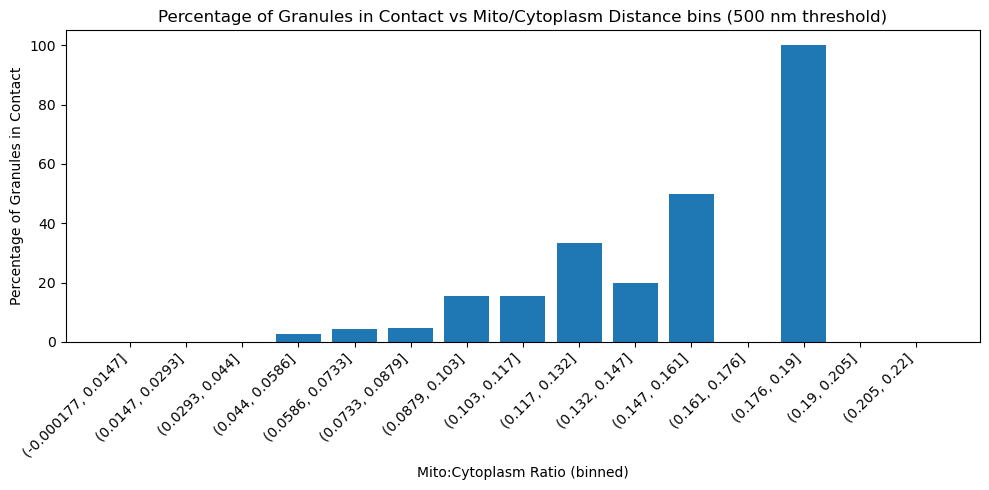

In [403]:
# Convert interval bins to strings for plotting
bin_labels = bin_summary["bin"].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    bin_labels,
    bin_summary["percent_ones"]
)

ax.set_xlabel("Mito:Cytoplasm Ratio (binned)")
ax.set_ylabel("Percentage of Granules in Contact")
ax.set_title("Percentage of Granules in Contact vs Mito/Cytoplasm Distance bins (500 nm threshold)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

# Performing Full Analysis

In [36]:
#NS Analysis
threshold_nm = 750

#1537_19
counts_df_1537_19, neigh_1537_19, dist_maps_1537_19, pad_slices_1537_19, labels_img_1537_19 = granule_neighborhood_overlap(
    NS_1537_19_files,
    LACfactor=LACfactordict["1537_19"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#7_22
counts_df_7_22, neigh_7_22, dist_maps_7_22, pad_slices_7_22, labels_img_7_22 = granule_neighborhood_overlap(
    NS_7_22_files,
    LACfactor=LACfactordict["7_22"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#6_5
counts_df_6_5, neigh_6_5, dist_maps_6_5, pad_slices_6_5, labels_img_6_5 = granule_neighborhood_overlap(
    NS_6_5_files,
    LACfactor=LACfactordict["6_5"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#1537_16_18
counts_df_1537_16_18, neigh_1537_16_18, dist_maps_1537_16_18, pad_slices_1537_16_18, labels_img_1537_16_18 = granule_neighborhood_overlap(
    NS_1537_16_18_files,
    LACfactor=LACfactordict["1537_16-18"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#7_8_9
counts_df_7_8_9, neigh_7_8_9, dist_maps_7_8_9, pad_slices_7_8_9, labels_img_7_8_9 = granule_neighborhood_overlap(
    NS_7_8_9_files,
    LACfactor=LACfactordict["7_8=9"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#6_17_19
counts_df_6_17_19, neigh_6_17_19, dist_maps_6_17_19, pad_slices_6_17_19, labels_img_6_17_19 = granule_neighborhood_overlap(
    NS_6_17_19_files,
    LACfactor=LACfactordict["6_17-19"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang

In [37]:
count_df_concat = pd.concat(
    [
        counts_df_1537_19.assign(Cell="1537_19"),
        counts_df_7_22.assign(Cell="7_22"),
        counts_df_6_5.assign(Cell="6_5"),
        counts_df_1537_16_18.assign(Cell="1537_16_18"),
        counts_df_7_8_9.assign(Cell="7_8_9"),
        counts_df_6_17_19.assign(Cell="6_17_19"),
    ],
    ignore_index=True
)

In [38]:
#save dataframe for othernotebook
count_df_concat.to_pickle("count_df_concat.pkl")

count_df_concat
#count_df_concat_1000nm = count_df_concat

,label,cyto_voxels,mito_voxels,mito_over_cyto_voxels,mito_within_50nm,mito_within_50nm_flag,Centroid X,Centroid Y,Centroid Z,LAC Value,...,LAC Min,LAC Std Dev,LAC Skew,LAC Kurtosis,LAC Median,LAC 25th Quantile,LAC 75th Quantile,Volume (um3),Geometric Diameter (nm),Cell
0,1,38771,1030,0.026566,0,0,73.237500,263.700000,252.012500,0.307060,...,0.256875,0.022202,-0.183304,-0.761685,0.309746,0.288654,0.323563,0.002161,150.015002,1537_19
1,2,56410,1297,0.022992,0,0,76.850877,383.903509,215.754386,0.300995,...,0.254046,0.022650,0.144516,-0.389380,0.300367,0.285002,0.315677,0.003079,169.403426,1537_19
2,3,52927,4856,0.091749,0,0,75.581818,384.818182,271.072727,0.328830,...,0.283468,0.019944,-0.112387,-0.285448,0.327869,0.318648,0.343884,0.001485,117.457775,1537_19
3,4,62511,3818,0.061077,0,0,78.165049,294.111650,236.757282,0.343917,...,0.298872,0.021490,0.751627,1.180491,0.341721,0.329744,0.357138,0.005564,208.582457,1537_19
4,5,56269,3363,0.059766,0,0,77.333333,319.015873,244.650794,0.321087,...,0.265886,0.021179,0.025024,-0.163167,0.320079,0.304747,0.336763,0.001702,139.261591,1537_19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6018,1373,43389,762,0.017562,0,0,370.096774,299.709677,231.645161,0.305471,...,0.283239,0.014765,0.667135,-0.312184,0.299941,0.295175,0.316503,0.001067,85.255088,6_17_19
6019,1374,49082,301,0.006133,0,0,370.990654,412.355140,170.691589,0.308251,...,0.280399,0.015837,0.397342,-0.696306,0.307293,0.295381,0.318948,0.003684,187.670731,6_17_19
6020,1375,41463,0,0.000000,0,0,372.258621,311.224138,236.603448,0.275697,...,0.250028,0.018281,0.534131,-0.496250,0.272935,0.258691,0.287270,0.001997,150.995082,6_17_19
6021,1376,43179,0,0.000000,0,0,372.051724,328.758621,232.379310,0.311265,...,0.276166,0.018096,0.251138,-0.541309,0.310131,0.294641,0.322342,0.001997,140.171418,6_17_19


In [39]:
type(count_df_concat)

pandas.core.frame.DataFrame

In [40]:
#where above 0 mito ratio. Keep only mito/cytoplasm ratio, as well as if in contact or not
subset_counts_concat = count_df_concat[count_df_concat["mito_over_cyto_voxels"] > 0]

subset_counts_concat

,label,cyto_voxels,mito_voxels,mito_over_cyto_voxels,mito_within_50nm,mito_within_50nm_flag,Centroid X,Centroid Y,Centroid Z,LAC Value,...,LAC Min,LAC Std Dev,LAC Skew,LAC Kurtosis,LAC Median,LAC 25th Quantile,LAC 75th Quantile,Volume (um3),Geometric Diameter (nm),Cell
0,1,38771,1030,0.026566,0,0,73.237500,263.700000,252.012500,0.307060,...,0.256875,0.022202,-0.183304,-0.761685,0.309746,0.288654,0.323563,0.002161,150.015002,1537_19
1,2,56410,1297,0.022992,0,0,76.850877,383.903509,215.754386,0.300995,...,0.254046,0.022650,0.144516,-0.389380,0.300367,0.285002,0.315677,0.003079,169.403426,1537_19
2,3,52927,4856,0.091749,0,0,75.581818,384.818182,271.072727,0.328830,...,0.283468,0.019944,-0.112387,-0.285448,0.327869,0.318648,0.343884,0.001485,117.457775,1537_19
3,4,62511,3818,0.061077,0,0,78.165049,294.111650,236.757282,0.343917,...,0.298872,0.021490,0.751627,1.180491,0.341721,0.329744,0.357138,0.005564,208.582457,1537_19
4,5,56269,3363,0.059766,0,0,77.333333,319.015873,244.650794,0.321087,...,0.265886,0.021179,0.025024,-0.163167,0.320079,0.304747,0.336763,0.001702,139.261591,1537_19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6016,1371,42607,2153,0.050532,0,0,366.428571,271.571429,246.657143,0.317071,...,0.301191,0.009543,0.618332,0.242089,0.315129,0.311165,0.323838,0.001205,107.414680,6_17_19
6017,1372,43748,404,0.009235,0,0,366.000000,370.638889,156.416667,0.289549,...,0.271175,0.011167,0.216885,-0.981204,0.288257,0.281564,0.297827,0.001239,101.081083,6_17_19
6018,1373,43389,762,0.017562,0,0,370.096774,299.709677,231.645161,0.305471,...,0.283239,0.014765,0.667135,-0.312184,0.299941,0.295175,0.316503,0.001067,85.255088,6_17_19
6019,1374,49082,301,0.006133,0,0,370.990654,412.355140,170.691589,0.308251,...,0.280399,0.015837,0.397342,-0.696306,0.307293,0.295381,0.318948,0.003684,187.670731,6_17_19


In [41]:
# Create 10 bins
subset_counts_concat["bin"] = pd.cut(
    subset_counts_concat["mito_over_cyto_voxels"],
    bins=30
)

# Calculate percentage of 1s in each bin
bin_summary_concat = (
    subset_counts_concat
    .groupby("bin")["mito_within_50nm_flag"]
    .agg(
        total="count",
        positives="sum"
    )
    .assign(
        percent_ones=lambda x: 100 * x["positives"] / x["total"]
    )
    .reset_index()
)

print(bin_summary_concat)

                     bin  total  positives  percent_ones
0   (-0.000268, 0.00928]    864          0      0.000000
1      (0.00928, 0.0186]    557          2      0.359066
2       (0.0186, 0.0278]    495          5      1.010101
3       (0.0278, 0.0371]    417          6      1.438849
4       (0.0371, 0.0464]    381          8      2.099738
5       (0.0464, 0.0557]    321         15      4.672897
6       (0.0557, 0.0649]    298         19      6.375839
7       (0.0649, 0.0742]    222         15      6.756757
8       (0.0742, 0.0835]    175         12      6.857143
9       (0.0835, 0.0928]    141         16     11.347518
10       (0.0928, 0.102]    129         17     13.178295
11        (0.102, 0.111]     91         11     12.087912
12        (0.111, 0.121]     65         10     15.384615
13         (0.121, 0.13]     55         10     18.181818
14         (0.13, 0.139]     44          9     20.454545
15        (0.139, 0.148]     33         13     39.393939
16        (0.148, 0.158]     29

C:\Users\kchang42\AppData\Local\Temp\ipykernel_51244\1496550847.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_counts_concat["bin"] = pd.cut(
C:\Users\kchang42\AppData\Local\Temp\ipykernel_51244\1496550847.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")["mito_within_50nm_flag"]


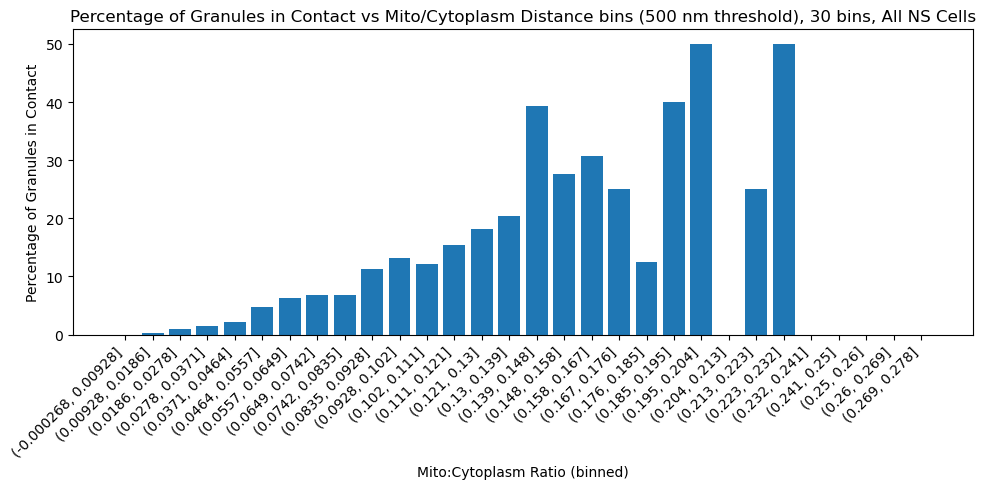

In [42]:
# Convert interval bins to strings for plotting
bin_labels_concat = bin_summary_concat["bin"].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    bin_labels_concat,
    bin_summary_concat["percent_ones"]
)

ax.set_xlabel("Mito:Cytoplasm Ratio (binned)")
ax.set_ylabel("Percentage of Granules in Contact")
ax.set_title("Percentage of Granules in Contact vs Mito/Cytoplasm Distance bins (500 nm threshold), 30 bins, All NS Cells")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig("MitoDensity_contact_1000.png",dpi=300,bbox_inches="tight")

plt.show()

In [43]:
subset_counts_concat

,label,cyto_voxels,mito_voxels,mito_over_cyto_voxels,mito_within_50nm,mito_within_50nm_flag,Centroid X,Centroid Y,Centroid Z,LAC Value,...,LAC Std Dev,LAC Skew,LAC Kurtosis,LAC Median,LAC 25th Quantile,LAC 75th Quantile,Volume (um3),Geometric Diameter (nm),Cell,bin
0,1,38771,1030,0.026566,0,0,73.237500,263.700000,252.012500,0.307060,...,0.022202,-0.183304,-0.761685,0.309746,0.288654,0.323563,0.002161,150.015002,1537_19,"(0.0186, 0.0278]"
1,2,56410,1297,0.022992,0,0,76.850877,383.903509,215.754386,0.300995,...,0.022650,0.144516,-0.389380,0.300367,0.285002,0.315677,0.003079,169.403426,1537_19,"(0.0186, 0.0278]"
2,3,52927,4856,0.091749,0,0,75.581818,384.818182,271.072727,0.328830,...,0.019944,-0.112387,-0.285448,0.327869,0.318648,0.343884,0.001485,117.457775,1537_19,"(0.0835, 0.0928]"
3,4,62511,3818,0.061077,0,0,78.165049,294.111650,236.757282,0.343917,...,0.021490,0.751627,1.180491,0.341721,0.329744,0.357138,0.005564,208.582457,1537_19,"(0.0557, 0.0649]"
4,5,56269,3363,0.059766,0,0,77.333333,319.015873,244.650794,0.321087,...,0.021179,0.025024,-0.163167,0.320079,0.304747,0.336763,0.001702,139.261591,1537_19,"(0.0557, 0.0649]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6016,1371,42607,2153,0.050532,0,0,366.428571,271.571429,246.657143,0.317071,...,0.009543,0.618332,0.242089,0.315129,0.311165,0.323838,0.001205,107.414680,6_17_19,"(0.0464, 0.0557]"
6017,1372,43748,404,0.009235,0,0,366.000000,370.638889,156.416667,0.289549,...,0.011167,0.216885,-0.981204,0.288257,0.281564,0.297827,0.001239,101.081083,6_17_19,"(-0.000268, 0.00928]"
6018,1373,43389,762,0.017562,0,0,370.096774,299.709677,231.645161,0.305471,...,0.014765,0.667135,-0.312184,0.299941,0.295175,0.316503,0.001067,85.255088,6_17_19,"(0.00928, 0.0186]"
6019,1374,49082,301,0.006133,0,0,370.990654,412.355140,170.691589,0.308251,...,0.015837,0.397342,-0.696306,0.307293,0.295381,0.318948,0.003684,187.670731,6_17_19,"(-0.000268, 0.00928]"


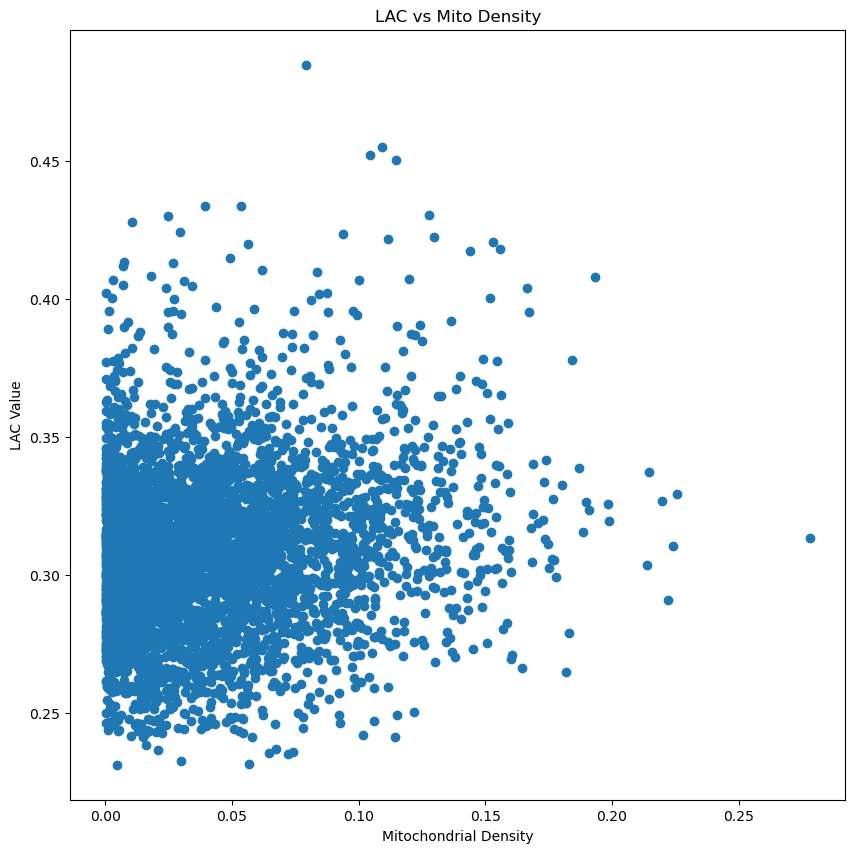

In [44]:
x_dat_mito = subset_counts_concat["mito_over_cyto_voxels"]
y_dat_LAC = subset_counts_concat["LAC Value"]

plt.figure(figsize=(10,10))
plt.scatter(x_dat_mito, y_dat_LAC)

plt.xlabel("Mitochondrial Density")
plt.ylabel("LAC Value")
plt.title("LAC vs Mito Density")

plt.show()

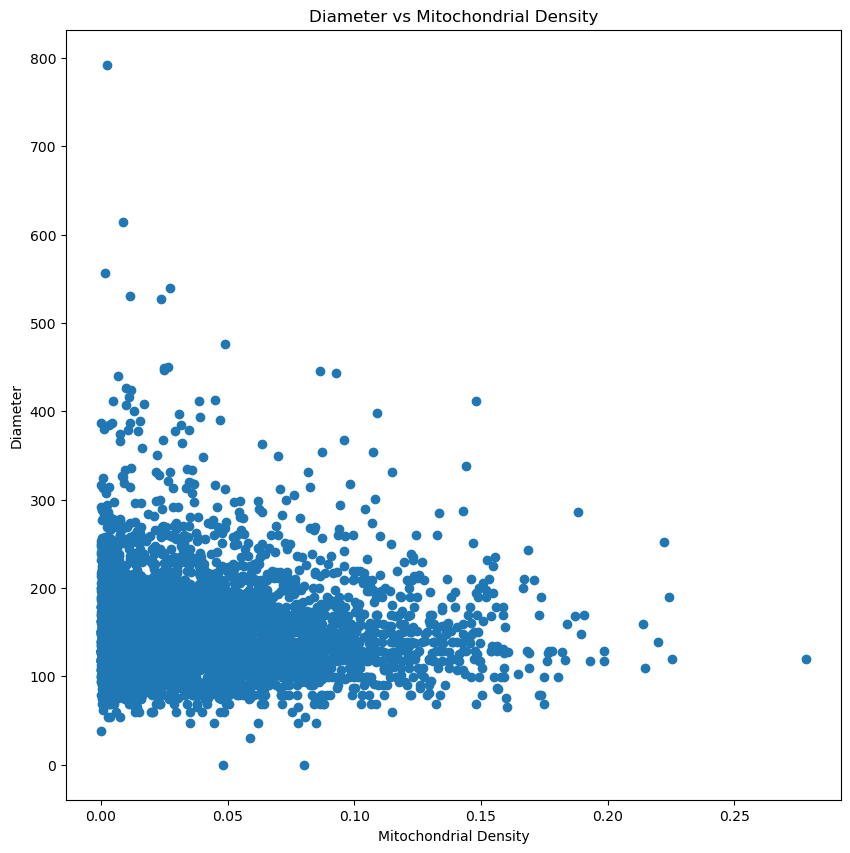

In [45]:
x_dat_mito = subset_counts_concat["mito_over_cyto_voxels"]
y_dat_diam = subset_counts_concat["Geometric Diameter (nm)"]

plt.figure(figsize=(10,10))
plt.scatter(x_dat_mito, y_dat_diam)

plt.xlabel("Mitochondrial Density")
plt.ylabel("Diameter")
plt.title("Diameter vs Mitochondrial Density")

plt.show()